# НИРМ3 — Неделя 1: подключение датасета PTB-XL

Продолжение `sist_research.ipynb` (НИРМ2, Cleveland + XGBoost + SHAP).
Задача недели: скачать PTB-XL, изучить структуру, посчитать баланс классов, посмотреть на пример сигнала.


In [5]:
# 1. Установка зависимостей
!pip install wfdb --quiet

In [6]:
!wget -q --show-progress https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip -O ptbxl.zip
!unzip -q ptbxl.zip
!mv "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3" ptbxl

ptbxl.zip           100%[===================>]   1.71G   257KB/s    in 2h 14m  


In [10]:
import glob
paths = glob.glob('**/ptbxl_database.csv', recursive=True)
print(paths)

['ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv']


In [11]:
import pandas as pd
import numpy as np
import ast
import wfdb
import matplotlib.pyplot as plt

DATA_PATH = 'ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'

df = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

agg_df = pd.read_csv(DATA_PATH + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

print('Всего записей:', len(df))
df.head()

Всего записей: 21799


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [12]:
def aggregate_diagnostic(scp_codes):
    classes = set()
    for code in scp_codes.keys():
        if code in agg_df.index:
            classes.add(agg_df.loc[code].diagnostic_class)
    return list(classes)

df['superclass'] = df.scp_codes.apply(aggregate_diagnostic)

from collections import Counter
counts = Counter([c for classes in df['superclass'] for c in classes])
print('Баланс суперклассов:')
for cls, n in counts.most_common():
    print(f'  {cls}: {n} ({n/len(df)*100:.1f}%)')

no_label = df['superclass'].apply(len).eq(0).sum()
print(f'\nБез диагностической метки: {no_label} ({no_label/len(df)*100:.1f}%)')

Баланс суперклассов:
  NORM: 9514 (43.6%)
  MI: 5469 (25.1%)
  STTC: 5235 (24.0%)
  CD: 4898 (22.5%)
  HYP: 2649 (12.2%)

Без диагностической метки: 411 (1.9%)


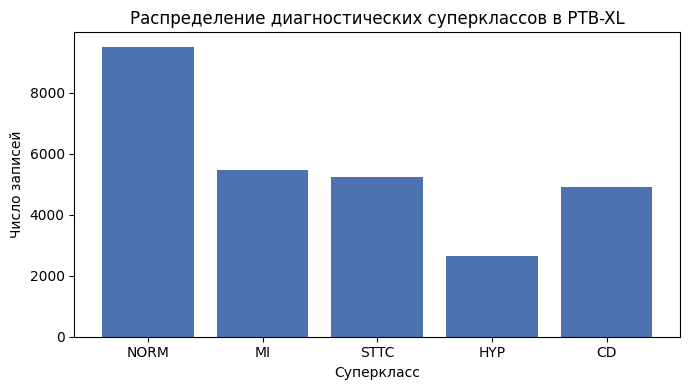

In [13]:
plt.figure(figsize=(7,4))
plt.bar(counts.keys(), counts.values(), color='#4C72B0')
plt.title('Распределение диагностических суперклассов в PTB-XL')
plt.ylabel('Число записей')
plt.xlabel('Суперкласс')
plt.tight_layout()
plt.show()

Форма сигнала (отсчёты x отведения): (1000, 12)
Частота дискретизации: 100 Гц
Отведения: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


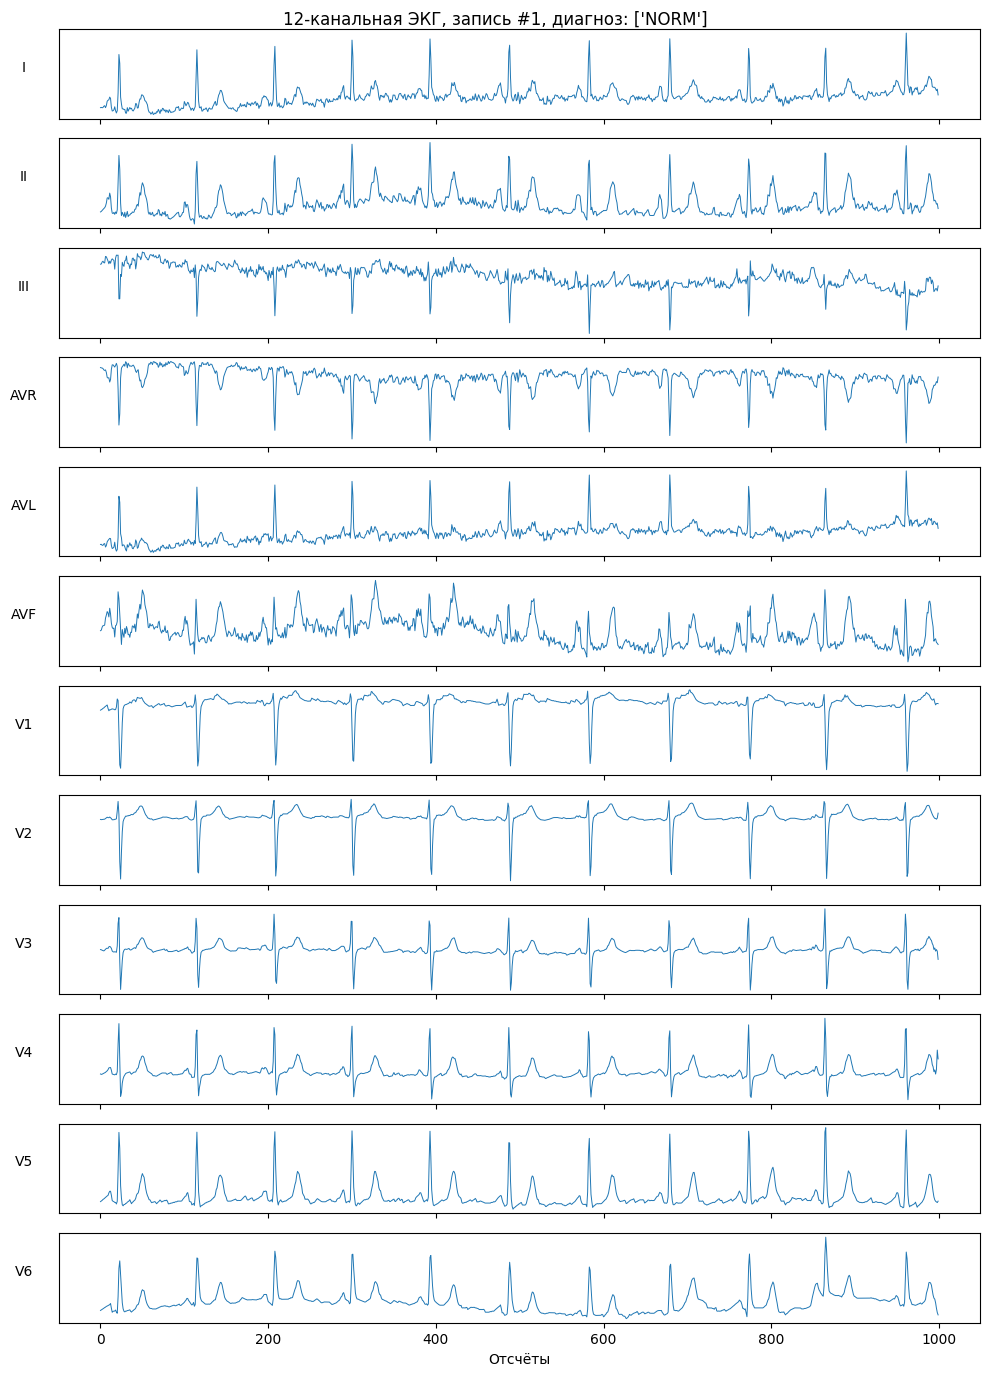

In [14]:
example_id = df.index[0]
example_path = DATA_PATH + df.loc[example_id].filename_lr  # 100Hz версия

signal, meta = wfdb.rdsamp(example_path)
print('Форма сигнала (отсчёты x отведения):', signal.shape)
print('Частота дискретизации:', meta['fs'], 'Гц')
print('Отведения:', meta['sig_name'])

fig, axes = plt.subplots(12, 1, figsize=(10, 14), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(signal[:, i], linewidth=0.7)
    ax.set_ylabel(meta['sig_name'][i], rotation=0, labelpad=25)
    ax.set_yticks([])
axes[-1].set_xlabel('Отсчёты')
fig.suptitle(f'12-канальная ЭКГ, запись #{example_id}, диагноз: {df.loc[example_id].superclass}')
plt.tight_layout()
plt.show()

## Выводы недели 1

- Датасет PTB-XL подключён, структура изучена: 21837 записей, метаданные + сигналы в формате WFDB.
- Диагнозы смаппированы на 5 суперклассов (NORM/MI/STTC/CD/HYP), посчитан баланс — есть выраженный дисбаланс в пользу NORM, что нужно будет учитывать (SMOTE / class weights), аналогично подходу из НИРМ2 (scale_pos_weight в XGBoost).
- Прочитан и визуализирован пример 12-канальной ЭКГ.
- Следующий шаг (неделя 2): полноценный EDA — распределение по возрасту/полу, длительность записей, качество сигналов (шумы, артефакты), выбор между records100 (100Hz) и records500 (500Hz) для дальнейшего обучения моделей.